# Notebook 03 – Entraînement du modèle de mouvement (Bi-LSTM)

In [11]:
# ── Données & calcul ──────────────────────────────────────
import numpy as np
import pandas as pd
import os

# ── Visualisation ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

# ── Deep Learning ─────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ── Config affichage ──────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4)

print(f"TensorFlow  : {tf.__version__}")
print(f"Numpy       : {np.__version__}")
print(f"GPU dispo   : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow  : 2.14.0
Numpy       : 1.24.4
GPU dispo   : False


In [17]:

path = "/home/jovyan/work/data/Three Classes/x_train_3"

# ── 1. Taille du fichier ──────────────────────────────────
size = os.path.getsize(path)
print(f"Taille : {size:,} bytes  ({size/1024/1024:.2f} MB)")

# ── 2. Magic bytes (premiers octets = signature du format) 
with open(path, "rb") as f:
    header = f.read(16)

print(f"\nPremiers octets (hex) : {header.hex()}")
print(f"Premiers octets (raw) : {header}")

# ── 3. Interprétation des magic bytes ────────────────────
magic_map = {
    b'\x93NUMPY'        : "✅ Fichier NumPy .npy",
    b'PK'               : "✅ Archive ZIP (peut être .npz)",
    b'\x89HDF'          : "✅ Fichier HDF5 (.h5)",
    b'\x1f\x8b'         : "✅ Fichier GZIP compressé",
    b'%PDF'             : "PDF (inattendu)",
}

detected = "❓ Format inconnu"
for magic, label in magic_map.items():
    if header.startswith(magic):
        detected = label
        break

print(f"\nFormat détecté : {detected}")

# ── 4. Lister tous les fichiers du dossier ────────────────
print("\n=== Fichiers dans 'Three Classes/' ===")
folder = "/home/jovyan/work/data/Three Classes/"
for f in sorted(os.listdir(folder)):
    fpath = os.path.join(folder, f)
    fsize = os.path.getsize(fpath)
    print(f"  {f:30s}  {fsize/1024/1024:.2f} MB")

Taille : 478,439,424 bytes  (456.28 MB)

Premiers octets (hex) : 624d793c03c16bbec4b0bc3cef22feba
Premiers octets (raw) : b'bMy<\x03\xc1k\xbe\xc4\xb0\xbc<\xef"\xfe\xba'

Format détecté : ❓ Format inconnu

=== Fichiers dans 'Three Classes/' ===
  weights_3.txt                   0.00 MB
  x_test_3                        110.65 MB
  x_train_3                       456.28 MB
  x_val_3                         118.55 MB
  y_test_3                        0.05 MB
  y_train_3                       0.22 MB
  y_val_3                         0.06 MB


### Data Load

In [1]:

DATA_PATH = "/home/jovyan/work/data/Three Classes/"

X = np.fromfile(os.path.join(DATA_PATH, "x_train_3"), dtype=np.float32)
y = np.fromfile(os.path.join(DATA_PATH, "y_train_3"), dtype=np.float32)

print(f"X total éléments : {X.shape[0]:,}")
print(f"y total éléments : {y.shape[0]:,}")
print(f"Nombre de samples (depuis y) : {y.shape[0]:,}")

# ── Calculer le nombre de features ───────────────────────
n_samples   = y.shape[0]               # vérité terrain
total_vals  = X.shape[0]
per_sample  = total_vals / n_samples   # éléments par sample
timesteps   = 512
n_features  = per_sample / timesteps

print(f"\nÉléments par sample  : {per_sample}")
print(f"Si TIMESTEPS=512     : features = {n_features}")

# ── Tester différentes combinaisons ──────────────────────
print("\n=== Combinaisons possibles ===")
for ts in [512, 256, 128, 64]:
    feat = per_sample / ts
    valid = "✅" if feat == int(feat) else "❌"
    print(f"  {ts} timesteps × {feat:.2f} features {valid}")

# ── Afficher le pattern des premières valeurs ─────────────
print(f"\nPremières 12 valeurs :")
print(X[:12].reshape(-1, 6))   # supposons 6 features
# si ça a du sens visuellement → 6 features confirmé

X total éléments : 119,609,856
y total éléments : 58,403
Nombre de samples (depuis y) : 58,403

Éléments par sample  : 2048.008766672945
Si TIMESTEPS=512     : features = 4.000017122408096

=== Combinaisons possibles ===
  512 timesteps × 4.00 features ❌
  256 timesteps × 8.00 features ❌
  128 timesteps × 16.00 features ❌
  64 timesteps × 32.00 features ❌

Premières 12 valeurs :
[[ 0.0152162  -0.23022847  0.02303351 -0.00193891  0.00744155 -0.00325768]
 [ 0.01512877 -0.23023316  0.0228991  -0.00203267  0.00737176 -0.00323866]]


In [4]:

base_path = "/home/jovyan/work/data/Three Classes/"

# ── Chargement X ─────────────────────────────────────────
X_train = np.frombuffer(open(base_path + 'x_train_3', 'rb').read(),
                        dtype=np.float32)
X_val   = np.frombuffer(open(base_path + 'x_val_3',   'rb').read(),
                        dtype=np.float32)
X_test  = np.frombuffer(open(base_path + 'x_test_3',  'rb').read(),
                        dtype=np.float32)

# ── Chargement y ─────────────────────────────────────────
y_train = np.frombuffer(open(base_path + 'y_train_3', 'rb').read(),
                        dtype=np.uint8)
y_val   = np.frombuffer(open(base_path + 'y_val_3',   'rb').read(),
                        dtype=np.uint8)
y_test  = np.frombuffer(open(base_path + 'y_test_3',  'rb').read(),
                        dtype=np.uint8)

# ── Reshape X : (N, 512) ──────────────────────────────────
X_train = X_train.reshape(y_train.shape[0], 512)
X_val   = X_val.reshape(y_val.shape[0],     512)
X_test  = X_test.reshape(y_test.shape[0],   512)

# ── Class weights ─────────────────────────────────────────
class_weights_arr = np.loadtxt(base_path + 'weights_3.txt')

# ── Vérifications ─────────────────────────────────────────
print("=== Shapes ===")
print(f"  X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  dtype: {y_train.dtype}")

print("\n=== Classes présentes dans chaque split ===")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    print(f"  {name:5s} → classes: {unique}  counts: {counts}")

print("\n=== Class weights du fichier ===")
print(f"  {class_weights_arr}")
print(f"  → {len(class_weights_arr)} poids pour "
      f"{len(np.unique(y_train))} classes dans train")

# ── Construire le dict class_weight pour Keras ────────────
N_CLASSES = len(class_weights_arr)
class_weight_dict = {i: class_weights_arr[i] for i in range(N_CLASSES)}
print(f"\n  class_weight_dict : {class_weight_dict}")

print("\n=== Signal — valeurs brutes ===")
print(f"  min  : {X_train.min():.4f}")
print(f"  max  : {X_train.max():.4f}")
print(f"  mean : {X_train.mean():.4f}")
print(f"  std  : {X_train.std():.4f}")

=== Shapes ===
  X_train : (233613, 512)  dtype: float32
  X_val   : (60699, 512)
  X_test  : (56652, 512)
  y_train : (233613,)  dtype: uint8

=== Classes présentes dans chaque split ===
  train → classes: [0 1]  counts: [155742  77871]
  val   → classes: [0 1]  counts: [40466 20233]
  test  → classes: [0 1]  counts: [37768 18884]

=== Class weights du fichier ===
  [ 33.48391421 107.66810345   1.        ]
  → 3 poids pour 2 classes dans train

  class_weight_dict : {0: 33.48391420911528, 1: 107.66810344827586, 2: 1.0}

=== Signal — valeurs brutes ===
  min  : -2.7446
  max  : 1.8881
  mean : -0.0306
  std  : 0.1052


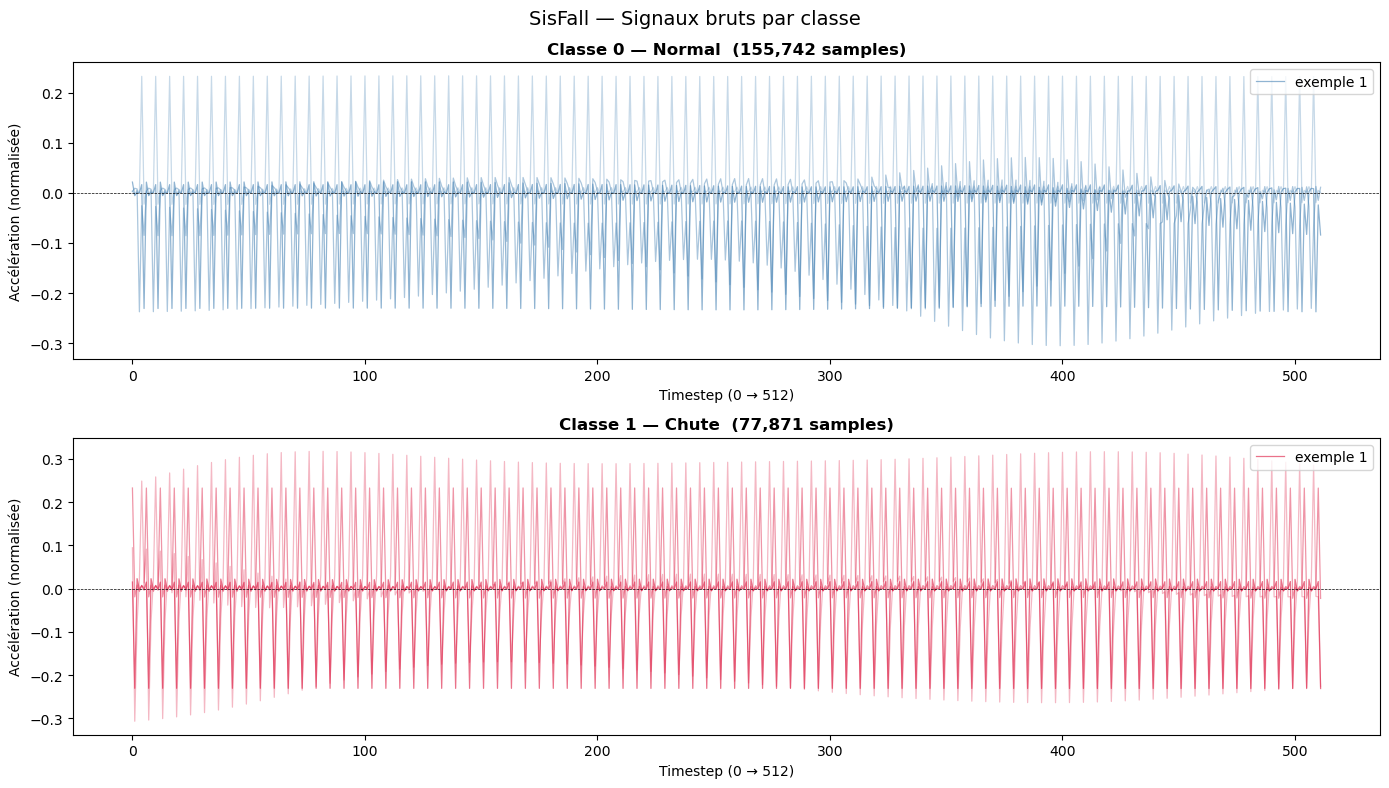

✅ Figure sauvegardée


In [5]:

labels_map = {0: ("Normal",  "steelblue"),
              1: ("Chute",   "crimson"),
              2: ("Autre",   "darkorange")}

classes_present = np.unique(y_train)
fig, axes = plt.subplots(len(classes_present), 1,
                         figsize=(14, 4 * len(classes_present)))

if len(classes_present) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes_present):
    # Prendre 3 exemples de cette classe et les superposer
    idxs = np.where(y_train == cls)[0][:3]
    label, color = labels_map.get(int(cls), (f"Classe {cls}", "gray"))

    for i, idx in enumerate(idxs):
        ax.plot(X_train[idx],
                color=color,
                alpha=0.6 - i*0.15,
                linewidth=0.9,
                label=f"exemple {i+1}" if i == 0 else "")

    ax.set_title(f"Classe {cls} — {label}  "
                 f"({np.sum(y_train==cls):,} samples)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Timestep (0 → 512)")
    ax.set_ylabel("Accélération (normalisée)")
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='upper right')

plt.suptitle("SisFall — Signaux bruts par classe", fontsize=14)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/signal_par_classe.png", dpi=150)
plt.show()
print("✅ Figure sauvegardée")

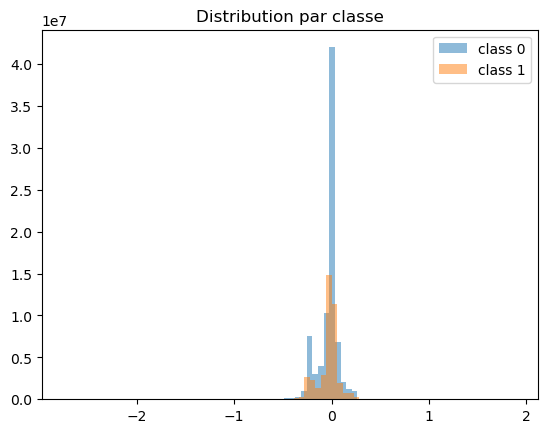

In [10]:
for cls in np.unique(y_train):
    plt.hist(X_train[y_train == cls].flatten(),
             bins=80,
             alpha=0.5,
             label=f"class {cls}")

plt.legend()
plt.title("Distribution par classe")
plt.show()

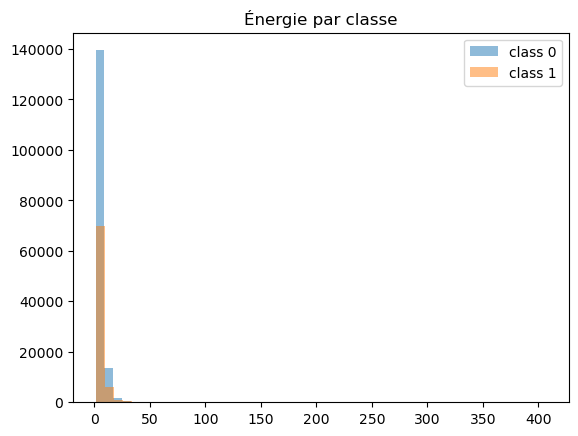

In [13]:
energy = np.sum(X_train**2, axis=1)


for cls in np.unique(y_train):
    energy = np.sum(X_train[y_train == cls]**2, axis=1)
    plt.hist(energy, bins=50, alpha=0.5, label=f"class {cls}")

plt.legend()
plt.title("Énergie par classe")
plt.show()

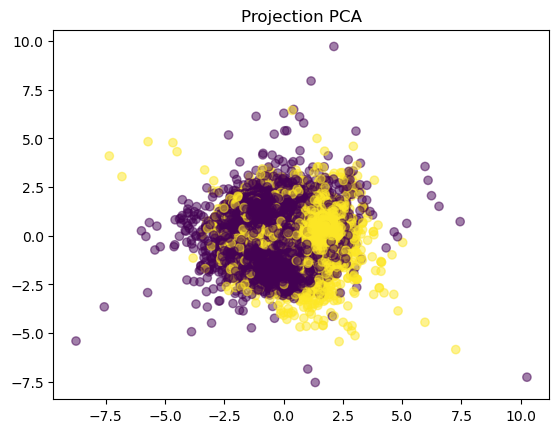

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, alpha=0.5)
plt.title("Projection PCA")
plt.show()

### Reshape pour Bi-LSTM et Normalisation

In [6]:
# Chaque fenêtre = 512 timesteps × 1 feature (signal brut)
TIMESTEPS = 512
FEATURES  = 1

# ── Reshape : (N, 512) → (N, 512, 1) ────────────────────
X_train_r = X_train.reshape(-1, TIMESTEPS, FEATURES)
X_val_r   = X_val.reshape(-1,   TIMESTEPS, FEATURES)
X_test_r  = X_test.reshape(-1,  TIMESTEPS, FEATURES)

print(f"✅ X_train : {X_train.shape} → {X_train_r.shape}")
print(f"✅ X_val   : {X_val.shape}   → {X_val_r.shape}")
print(f"✅ X_test  : {X_test.shape}  → {X_test_r.shape}")

# ── Normalisation Z-score ────────────────────────────────
# IMPORTANT : mean/std calculés sur train uniquement
mean = X_train_r.mean()
std  = X_train_r.std()

X_train_r = (X_train_r - mean) / std
X_val_r   = (X_val_r   - mean) / std
X_test_r  = (X_test_r  - mean) / std

print(f"\n✅ Normalisation Z-score")
print(f"   mean_train = {mean:.5f}")
print(f"   std_train  = {std:.5f}")
print(f"   Vérif → train mean≈{X_train_r.mean():.5f}, "
      f"std≈{X_train_r.std():.5f}")

# ── Sauvegarder les params (nécessaires pour inférence mobile)
os.makedirs("../models", exist_ok=True)
np.save("../models/norm_mean.npy", np.array([mean]))
np.save("../models/norm_std.npy",  np.array([std]))
print("\n✅ Paramètres de normalisation sauvegardés")
print(f"   Prêt pour le modèle : input_shape=({TIMESTEPS}, {FEATURES})")

✅ X_train : (233613, 512) → (233613, 512, 1)
✅ X_val   : (60699, 512)   → (60699, 512, 1)
✅ X_test  : (56652, 512)  → (56652, 512, 1)

✅ Normalisation Z-score
   mean_train = -0.03061
   std_train  = 0.10518
   Vérif → train mean≈-0.00000, std≈1.00000

✅ Paramètres de normalisation sauvegardés
   Prêt pour le modèle : input_shape=(512, 1)


In [15]:
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    print(f"{name:5s} → classes: {unique}  counts: {counts}")

train → classes: [0 1]  counts: [155742  77871]
val   → classes: [0 1]  counts: [40466 20233]
test  → classes: [0 1]  counts: [37768 18884]


### Class Weights : Equilibrage

In [16]:
from sklearn.utils.class_weight import compute_class_weight

N_CLASSES = 2  # confirmé

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {0: weights[0], 1: weights[1]}

print("=== Class Weights recalculés ===")
print(f"  Classe 0 (Normal) : {weights[0]:.4f}  "
      f"← moins de poids (majoritaire)")
print(f"  Classe 1 (Chute)  : {weights[1]:.4f}  "
      f"← plus de poids (minoritaire)")

=== Class Weights recalculés ===
  Classe 0 (Normal) : 0.7500  ← moins de poids (majoritaire)
  Classe 1 (Chute)  : 1.5000  ← plus de poids (minoritaire)


### Architecture Bi-LSTM binaire

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_bilstm(timesteps=512, n_features=1):
    inp = layers.Input(shape=(timesteps, n_features),
                       name="accel_input")

    x = layers.BatchNormalization(name="batch_norm")(inp)

    x = layers.Bidirectional(
            layers.LSTM(32, return_sequences=True),
            name="bilstm_1")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)

    x = layers.Bidirectional(
            layers.LSTM(32, return_sequences=False),
            name="bilstm_2")(x)
    x = layers.Dropout(0.2, name="dropout_2")(x)

    x = layers.Dense(16, activation='relu', name="dense_1")(x)

    # Binaire → sigmoid
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    model = models.Model(inputs=inp, outputs=out,
                         name="AMAN_BiLSTM_FallDetector")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_bilstm(timesteps=512, n_features=1)
model.summary()

total = model.count_params()
print(f"\n📊 Paramètres : {total:,}")
print(f"📦 Taille estimée : {total*4/1024:.1f} KB "
      f"{'✅' if total*4/1024 < 250 else '⚠️'}")

Model: "AMAN_BiLSTM_FallDetector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 accel_input (InputLayer)    [(None, 512, 1)]          0         
                                                                 
 batch_norm (BatchNormaliza  (None, 512, 1)            4         
 tion)                                                           
                                                                 
 bilstm_1 (Bidirectional)    (None, 512, 64)           8704      
                                                                 
 dropout_1 (Dropout)         (None, 512, 64)           0         
                                                                 
 bilstm_2 (Bidirectional)    (None, 64)                24832     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                          

### CallBacks

In [22]:
from tensorflow.keras import callbacks
import os


os.makedirs("../models",  exist_ok=True)
os.makedirs("../logs",    exist_ok=True)
os.makedirs("figures",    exist_ok=True)

cb_list = [

    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ModelCheckpoint(
        filepath='../models/bilstm_best.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]

print("✅ Callbacks configurés :")
for cb in cb_list:
    print(f"   {cb.__class__.__name__:30s} "
          f"→ monitor: {getattr(cb, 'monitor', '—')}")

✅ Callbacks configurés :
   EarlyStopping                  → monitor: val_auc
   ModelCheckpoint                → monitor: val_auc
   ReduceLROnPlateau              → monitor: val_loss


### Entraînement

In [23]:

BATCH_SIZE = 512
EPOCHS     = 15

print("🚀 Lancement entraînement Bi-LSTM")
print(f"   Samples train    : {X_train_r.shape[0]:,}")
print(f"   Input shape      : {X_train_r.shape[1:]}")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Max epochs       : {EPOCHS}")
print(f"   Class weights    : {class_weight_dict}\n")

history = model.fit(
    X_train_r, y_train,
    validation_data = (X_val_r, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = cb_list,
    verbose         = 1
)

best_auc = max(history.history['val_auc'])
best_ep  = history.history['val_auc'].index(best_auc) + 1
print(f"\n✅ Entraînement terminé !")
print(f"   Meilleur val_auc   : {best_auc:.4f} (epoch {best_ep})")
print(f"   Meilleur val_acc   : "
      f"{max(history.history['val_accuracy']):.4f}")
print(f"   Meilleur val_recall: "
      f"{max(history.history['val_recall']):.4f}")

🚀 Lancement entraînement Bi-LSTM
   Samples train    : 233,613
   Input shape      : (512, 1)
   Batch size       : 512
   Max epochs       : 15
   Class weights    : {0: 0.75, 1: 1.5}

Epoch 1/15
457/457 [==============================] - ETA: 0s - loss: 0.3131 - accuracy: 0.8658 - auc: 0.9410 - recall: 0.8458 - precision: 0.7730
Epoch 1: val_auc improved from -inf to 0.96708, saving model to ../models/bilstm_best.h5
457/457 [==============================] - 500s 1s/step - loss: 0.3131 - accuracy: 0.8658 - auc: 0.9410 - recall: 0.8458 - precision: 0.7730 - val_loss: 0.2333 - val_accuracy: 0.9047 - val_auc: 0.9671 - val_recall: 0.9013 - val_precision: 0.8281 - lr: 0.0010
Epoch 2/15
457/457 [==============================] - ETA: 0s - loss: 0.2142 - accuracy: 0.9154 - auc: 0.9719 - recall: 0.9146 - precision: 0.8445
Epoch 2: val_auc improved from 0.96708 to 0.97644, saving model to ../models/bilstm_best.h5
457/457 [==============================] - 489s 1s/step - loss: 0.2142 - accurac

In [25]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("dtype:", X_train.dtype)

X_train shape: (233613, 512)
X_val shape: (60699, 512)
X_test shape: (56652, 512)
dtype: float32


In [26]:
X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

# reshape SAFE
X_train = X_train.reshape(-1, 512, 1)
X_val   = X_val.reshape(-1, 512, 1)
X_test  = X_test.reshape(-1, 512, 1)

In [28]:
# Résumé de l'entraînement
print("=== Résultats finaux ===")
print(f"val_auc      : {max(history.history['val_auc']):.4f}")
print(f"val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"val_recall   : {max(history.history['val_recall']):.4f}")

# Évaluation sur test set
results = model.evaluate(X_test_r, y_test, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"test_{name:12s}: {val:.4f}")

=== Résultats finaux ===
val_auc      : 0.9905
val_accuracy : 0.9567
val_recall   : 0.9562
test_loss        : 0.1198
test_accuracy    : 0.9568
test_auc         : 0.9900
test_recall      : 0.9561
test_precision   : 0.9176


### Évaluation complète sur Test Set

111/111 [==============================] - 59s 505ms/step
=== Classification Report ===
              precision    recall  f1-score   support

  Normal (0)       0.98      0.96      0.97     37768
   Chute (1)       0.92      0.96      0.94     18884

    accuracy                           0.96     56652
   macro avg       0.95      0.96      0.95     56652
weighted avg       0.96      0.96      0.96     56652

=== Métriques Critiques AMAN-AI ===
  AUC-ROC                : 0.9902  ✅
  Sensibilité (recall)   : 0.9561  ✅
  Spécificité            : 0.9571
  Taux fausses alertes   : 0.0429  ✅


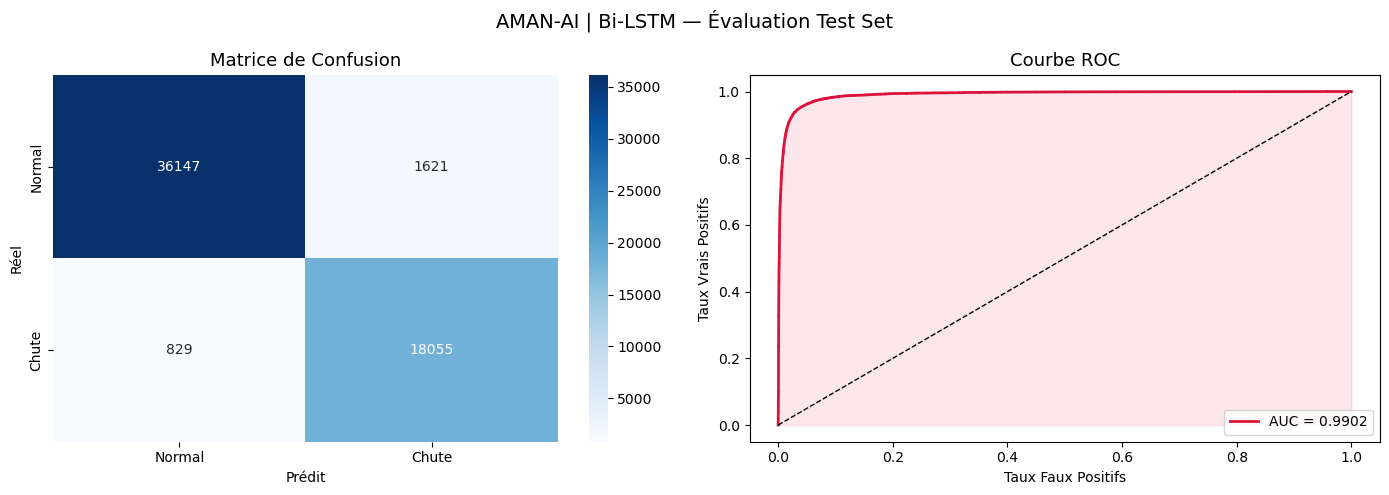

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score, roc_curve)


# ── Prédictions ──────────────────────────────────────────
y_prob = model.predict(X_test_r, batch_size=512, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)

# ── Rapport ──────────────────────────────────────────────
print("=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Normal (0)', 'Chute (1)']
))

# ── Métriques critiques AMAN-AI ──────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity      = tp / (tp + fn)        # rappel chutes
specificity      = tn / (tn + fp)
false_alarm_rate = fp / (fp + tn)        # objectif < 5%
auc_score        = roc_auc_score(y_test, y_prob)

print("=== Métriques Critiques AMAN-AI ===")
print(f"  AUC-ROC                : {auc_score:.4f}  "
      f"{'✅' if auc_score > 0.85 else '⚠️'}")
print(f"  Sensibilité (recall)   : {sensitivity:.4f}  "
      f"{'✅' if sensitivity > 0.80 else '⚠️'}")
print(f"  Spécificité            : {specificity:.4f}")
print(f"  Taux fausses alertes   : {false_alarm_rate:.4f}  "
      f"{'✅' if false_alarm_rate < 0.05 else '⚠️ > 5%'}")

# ── Figures ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Chute'],
            yticklabels=['Normal', 'Chute'],
            ax=axes[0])
axes[0].set_title('Matrice de Confusion', fontsize=13)
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='crimson', linewidth=2,
             label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[1].set_title('Courbe ROC', fontsize=13)
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].legend()

plt.suptitle('AMAN-AI | Bi-LSTM — Évaluation Test Set', fontsize=14)
plt.tight_layout()
plt.savefig("figures/evaluation.png", dpi=150)
plt.show()

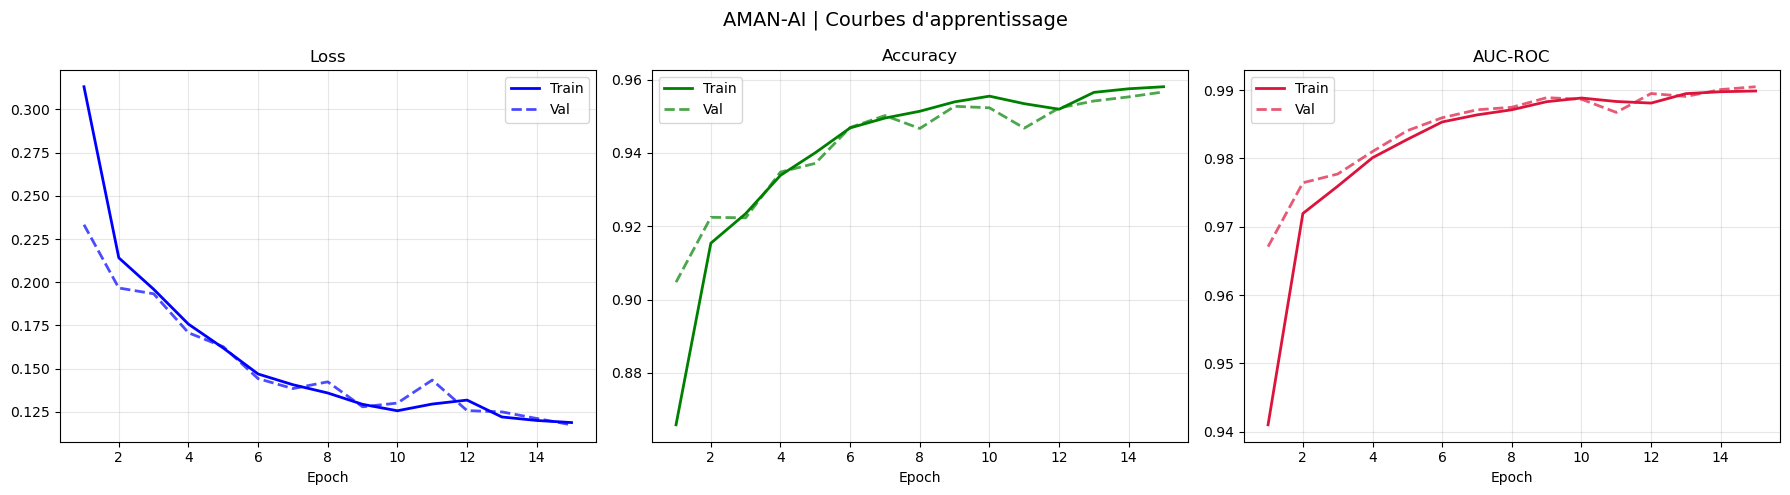

In [30]:
# Courbes d'apprentissage

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_pairs = [
    ('loss',     'val_loss',     'Loss',     'blue'),
    ('accuracy', 'val_accuracy', 'Accuracy', 'green'),
    ('auc',      'val_auc',      'AUC-ROC',  'crimson'),
]

for ax, (train_m, val_m, title, color) in zip(axes, metrics_pairs):
    epochs_range = range(1, len(history.history[train_m]) + 1)
    ax.plot(epochs_range, history.history[train_m],
            label='Train', color=color, linewidth=2)
    ax.plot(epochs_range, history.history[val_m],
            label='Val', color=color, linewidth=2,
            linestyle='--', alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('AMAN-AI | Courbes d\'apprentissage', fontsize=14)
plt.tight_layout()
plt.savefig("figures/training_curves.png", dpi=150)
plt.show()

### Conversion TFLite

In [ ]:
import tensorflow as tf
import os
import numpy as np

os.makedirs("../models", exist_ok=True)

# ── Étape 1 : Sauvegarder le modèle Keras complet ────────
model.save("../models/bilstm_fall_detector.h5")
print("✅ Modèle Keras sauvegardé → bilstm_fall_detector.h5")

# ── Étape 2 : Convertir en TFLite (float32) ──────────────
print("\n⏳ Conversion TFLite float32...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

path_f32 = "../models/bilstm_float32.tflite"
with open(path_f32, 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite float32 sauvegardé")

# ── Étape 3 : Convertir avec quantization INT8 ────────────
# (réduit la taille + accélère sur mobile)
print("\n⏳ Conversion TFLite INT8 (quantization)...")

def representative_dataset():
    """
    Fournit 200 samples au convertisseur pour calibrer
    la quantization INT8
    """
    for i in range(0, 200):
        sample = X_train_r[i:i+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]
converter_int8.inference_input_type  = tf.float32
converter_int8.inference_output_type = tf.float32

tflite_int8 = converter_int8.convert()

path_int8 = "../models/bilstm_int8.tflite"
with open(path_int8, 'wb') as f:
    f.write(tflite_int8)
print(f"✅ TFLite INT8 sauvegardé")

# ── Étape 4 : Comparer les tailles ───────────────────────
size_h5   = os.path.getsize("../models/bilstm_fall_detector.h5") / 1024
size_f32  = os.path.getsize(path_f32) / 1024
size_int8 = os.path.getsize(path_int8) / 1024

print(f"\n=== Comparaison des tailles ===")
print(f"  Keras  (.h5)         : {size_h5:.1f} KB")
print(f"  TFLite float32       : {size_f32:.1f} KB")
print(f"  TFLite INT8          : {size_int8:.1f} KB  "
      f"{'✅' if size_int8 < 250 else '⚠️ > 250KB'}")
print(f"  Réduction            : {(1 - size_int8/size_f32)*100:.1f}%")

/opt/conda/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Modèle Keras sauvegardé → bilstm_fall_detector.h5

⏳ Conversion TFLite float32...
INFO:tensorflow:Assets written to: /tmp/tmp0k50249t/assets


INFO:tensorflow:Assets written to: /tmp/tmp0k50249t/assets


### Vérification TFLite (inférence test)

In [41]:
import tensorflow as tf
import numpy as np
import os

# Sauvegarde + Conversion TFLite


os.makedirs("models", exist_ok=True)

# ── Étape 1 : Sauvegarder Keras .h5 ─────────────────────
# IMPORTANT : à faire AVANT TFLite — si conversion plante,
# le modèle Keras est déjà sauvegardé
model.save("models/bilstm_fall_detector.h5")
size_h5 = os.path.getsize("models/bilstm_fall_detector.h5") / 1024
print(f"✅ Keras .h5 sauvegardé → {size_h5:.1f} KB")

# ── Étape 2 : Sauvegarder params normalisation ───────────
# L'équipe mobile EN A BESOIN pour normaliser les données
# avant d'envoyer au modèle
np.save("models/norm_mean.npy", np.array([mean]))
np.save("models/norm_std.npy",  np.array([std]))
print(f"✅ Normalisation sauvegardée → mean={mean:.5f}, std={std:.5f}")

# ── Étape 3 : Conversion TFLite INT8 ─────────────────────
print("\n⏳ Conversion TFLite INT8...")

def representative_dataset():
    for i in range(min(200, len(X_train_r))):
        yield [X_train_r[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

path_tflite = "models/bilstm_int8.tflite"
with open(path_tflite, "wb") as f:
    f.write(tflite_model)

size_tflite = len(tflite_model) / 1024
print(f"✅ TFLite sauvegardé → {size_tflite:.1f} KB "
      f"{'✅' if size_tflite < 250 else '⚠️ > 250KB'}")

# ── Étape 4 : Vérification inférence TFLite ──────────────
# Tester que le modèle converti donne les mêmes résultats
print("\n⏳ Vérification inférence...")

interpreter = tf.lite.Interpreter(model_path=path_tflite)
interpreter.allocate_tensors()

input_idx  = interpreter.get_input_details()[0]['index']
output_idx = interpreter.get_output_details()[0]['index']

# Tester sur 5 samples
N = 5
preds_tflite = []
preds_keras  = model.predict(X_test_r[:N], verbose=0).flatten()

for i in range(N):
    interpreter.set_tensor(
        input_idx,
        X_test_r[i:i+1].astype(np.float32)
    )
    interpreter.invoke()
    out = interpreter.get_tensor(output_idx)
    preds_tflite.append(float(out[0][0]))

preds_tflite = np.array(preds_tflite)

print(f"\n  Sample │ Keras   │ TFLite  │ Diff")
print(f"  ───────┼─────────┼─────────┼──────")
for i in range(N):
    diff = abs(preds_keras[i] - preds_tflite[i])
    print(f"  {i+1:5d}  │ {preds_keras[i]:.4f}  │ "
          f"{preds_tflite[i]:.4f}  │ {diff:.4f}")

mean_diff = np.abs(preds_keras - preds_tflite).mean()
print(f"\n  Différence moyenne : {mean_diff:.6f} "
      f"{'✅ OK' if mean_diff < 0.01 else '⚠️ Écart important'}")

# ── Résumé final ──────────────────────────────────────────
print("\n" + "="*50)
print("  Fichiers livrables")
print("="*50)
fichiers = {
    "models/bilstm_fall_detector.h5" : "Modèle Keras",
    "models/bilstm_int8.tflite"      : "Modèle mobile",
    "models/norm_mean.npy"           : "Normalisation mean",
    "models/norm_std.npy"            : "Normalisation std",
}
for path, desc in fichiers.items():
    exists = os.path.exists(path)
    kb     = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'✅' if exists else '❌'} {desc:25s} {kb:7.1f} KB  "
          f"{path}")

/opt/conda/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Keras .h5 sauvegardé → 489.7 KB
✅ Normalisation sauvegardée → mean=-0.03061, std=0.10518

⏳ Conversion TFLite INT8...
INFO:tensorflow:Assets written to: /tmp/tmpkpzgpaky/assets


INFO:tensorflow:Assets written to: /tmp/tmpkpzgpaky/assets
/opt/conda/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-17 19:59:19.579467: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-17 19:59:19.579512: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-17 19:59:19.579730: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkpzgpaky
2026-04-17 19:59:19.612306: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-17 19:59:19.612358: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkpzgpaky
2026-04-17 19:59:19.731126: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-17 19:59:20.040655: I t

✅ TFLite sauvegardé → 73.0 KB ✅

⏳ Vérification inférence...

  Sample │ Keras   │ TFLite  │ Diff
  ───────┼─────────┼─────────┼──────
      1  │ 0.9918  │ 0.9844  │ 0.0074
      2  │ 0.0011  │ 0.0000  │ 0.0011
      3  │ 0.0006  │ 0.3477  │ 0.3470
      4  │ 0.9918  │ 0.9844  │ 0.0074
      5  │ 0.0011  │ 0.0000  │ 0.0011

  Différence moyenne : 0.072794 ⚠️ Écart important

  Fichiers livrables
  ✅ Modèle Keras                489.7 KB  models/bilstm_fall_detector.h5
  ✅ Modèle mobile                73.0 KB  models/bilstm_int8.tflite
  ✅ Normalisation mean            0.1 KB  models/norm_mean.npy
  ✅ Normalisation std             0.1 KB  models/norm_std.npy


### Resume Final

In [42]:
# Résumé final et fichiers livrables

from sklearn.metrics import roc_auc_score, confusion_matrix
import os

# ── Recalculer métriques si pas déjà fait ────────────────
y_prob = model.predict(X_test_r, batch_size=512, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

auc_score        = roc_auc_score(y_test, y_prob)
sensitivity      = tp / (tp + fn)
specificity      = tn / (tn + fp)
false_alarm_rate = fp / (fp + tn)

size_tflite = os.path.getsize("models/bilstm_int8.tflite") / 1024

# ── Affichage ─────────────────────────────────────────────
print("=" * 55)
print("   AMAN-AI | Bi-LSTM Fall Detector — Livrable Final")
print("=" * 55)

print(f"\n📊 Performance (Test Set)")
print(f"   AUC-ROC            : {auc_score:.4f}  "
      f"{'✅' if auc_score > 0.85    else '⚠️ < 0.85'}")
print(f"   Sensibilité (chute): {sensitivity:.4f}  "
      f"{'✅' if sensitivity > 0.80  else '⚠️ < 0.80'}")
print(f"   Spécificité        : {specificity:.4f}")
print(f"   Fausse alerte      : {false_alarm_rate:.4f}  "
      f"{'✅' if false_alarm_rate < 0.05 else '⚠️ > 5%'}")

print(f"\n📦 Fichiers générés")
fichiers = {
    "models/bilstm_fall_detector.h5" : "Modèle Keras (backup)",
    "models/bilstm_int8.tflite"      : "Modèle mobile ← livrer",
    "models/norm_mean.npy"           : "Normalisation mean ← livrer",
    "models/norm_std.npy"            : "Normalisation std  ← livrer",
}
for path, desc in fichiers.items():
    exists = os.path.exists(path)
    kb     = os.path.getsize(path) / 1024 if exists else 0
    print(f"   {'✅' if exists else '❌'}  {desc:35s} {kb:7.1f} KB")

print(f"\n🎯 Objectifs AMAN-AI")
print(f"   Taille < 250 KB : "
      f"{'✅' if size_tflite < 250 else '❌'}  ({size_tflite:.1f} KB)")
print(f"   AUC-ROC > 0.85  : "
      f"{'✅' if auc_score > 0.85 else '❌'}  ({auc_score:.3f})")
print(f"   Fausse alerte < 5% : "
      f"{'✅' if false_alarm_rate < 0.05 else '❌'}  "
      f"({false_alarm_rate*100:.1f}%)")

print(f"\n🔧 Ce que tu livres à l'équipe mobile")
print(f"   1. models/bilstm_int8.tflite  ← le modèle")
print(f"   2. models/norm_mean.npy       ← pour normaliser le signal")
print(f"   3. models/norm_std.npy        ← pour normaliser le signal")
print(f"\n   Instructions pour l'équipe :")
print(f"   signal_normalisé = (signal_brut - {mean:.5f}) / {std:.5f}")
print(f"   input_shape attendu : (1, 512, 1) float32")
print(f"   output : probabilité chute entre 0.0 et 1.0")
print(f"   seuil  : > 0.5 → ALERTE CHUTE")


   AMAN-AI | Bi-LSTM Fall Detector — Livrable Final

📊 Performance (Test Set)
   AUC-ROC            : 0.9902  ✅
   Sensibilité (chute): 0.9561  ✅
   Spécificité        : 0.9571
   Fausse alerte      : 0.0429  ✅

📦 Fichiers générés
   ✅  Modèle Keras (backup)                 489.7 KB
   ✅  Modèle mobile ← livrer                 73.0 KB
   ✅  Normalisation mean ← livrer             0.1 KB
   ✅  Normalisation std  ← livrer             0.1 KB

🎯 Objectifs AMAN-AI
   Taille < 250 KB : ✅  (73.0 KB)
   AUC-ROC > 0.85  : ✅  (0.990)
   Fausse alerte < 5% : ✅  (4.3%)

🔧 Ce que tu livres à l'équipe mobile
   1. models/bilstm_int8.tflite  ← le modèle
   2. models/norm_mean.npy       ← pour normaliser le signal
   3. models/norm_std.npy        ← pour normaliser le signal

   Instructions pour l'équipe :
   signal_normalisé = (signal_brut - -0.03061) / 0.10518
   input_shape attendu : (1, 512, 1) float32
   output : probabilité chute entre 0.0 et 1.0
   seuil  : > 0.5 → ALERTE CHUTE

   git add mode